# Load libraries

In [1]:
import numpy as np
import itertools, pandas as pd
from models import LinearModel, ChoquetModel
from pymoo_tests import ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2

import matplotlib.pyplot as plt
from utils import evaluate, visualise_weights

# Modelling

In [2]:
# ZDT calling
linear_model = LinearModel(problem = ZDT1(n_dim = 10), max_iter = 50, random_state = 42)
choquet_model = ChoquetModel(problem = ZDT1(n_dim = 10), max_iter = 50, random_state = 42, method = 2)

# DTLZ calling
# linear_model = LinearModel(problem = DTLZ1(n_dim = 10, n_obj = 3), max_iter = 50, random_state = 42)
# choquet_model = ChoquetModel(problem = DTLZ1(n_dim = 10, n_obj = 3), max_iter = 50, random_state = 42, method = 2)

# Let them solve
linear_model.solve()
choquet_model.solve()

# Summary their performance metrics

print(f"LinearModel :  PF {linear_model.PF.shape}  PS {linear_model.PS.shape}")
print(f"ChoquetModel:  PF {choquet_model.PF.shape} PS {choquet_model.PS.shape}")
evaluate([linear_model, choquet_model])

LinearModel :  PF (375, 2)  PS (375, 10)
ChoquetModel:  PF (248, 2) PS (248, 10)


,hypervolume,n_func_eval,n_non_dominated,n_iter,wallclock_time
LinearModel,5.508354,5346,754,50,0.437258
ChoquetModel,5.490907,3641,506,50,8.871389


# Model visualisation

In [3]:
# for kind in ["symmetric", "absolute", "norm"]:
#     visualise_weights(choquet_model, kind = kind);

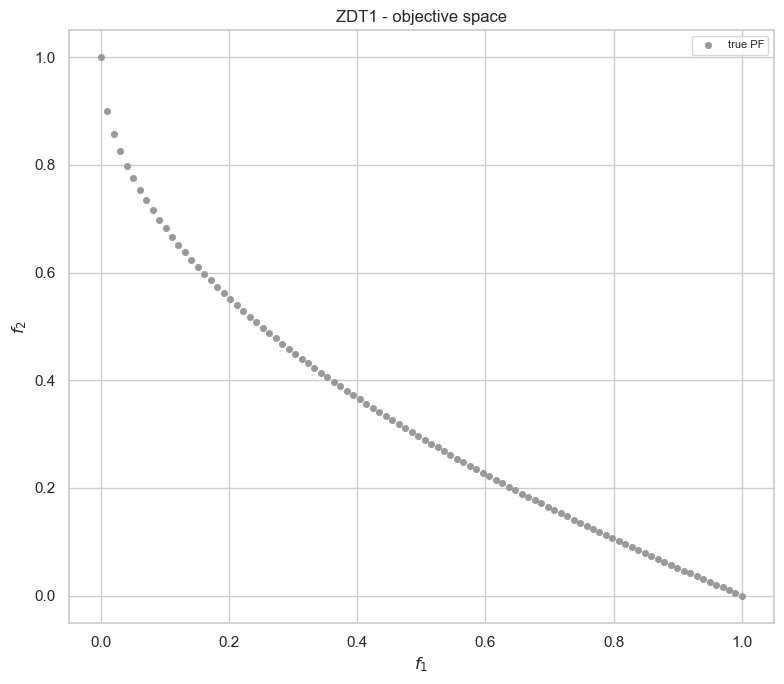

In [4]:
linear_model.visualise("true_pf");

## Linear Model

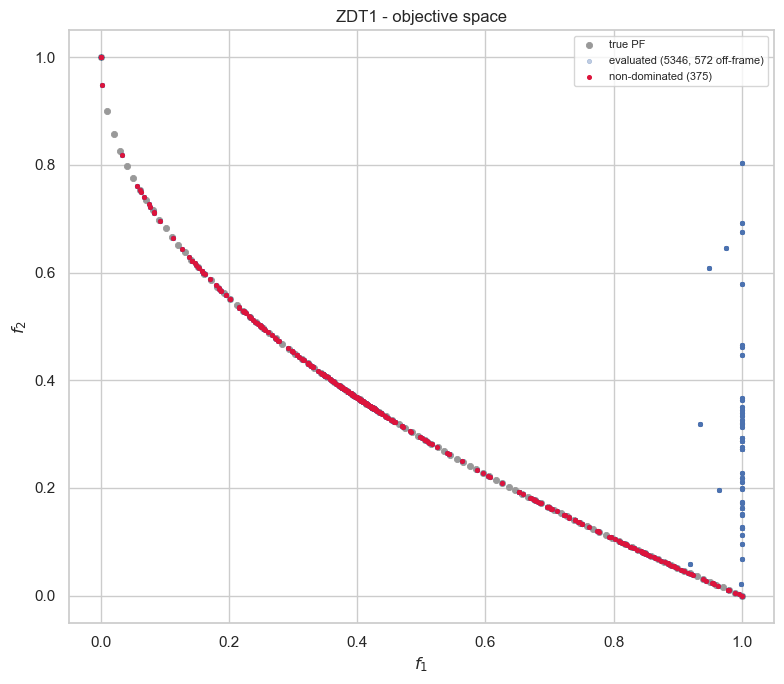

In [5]:
linear_model.visualise("objective");

In [6]:
linear_model.visualise("learning", show = False)

In [7]:
linear_model.visualise("learning", plot_scalarisation = True, show = False)

## Choquet Model

In [8]:
np.all((choquet_model.dec_hist >= 0) & (choquet_model.dec_hist <= 1))

np.True_

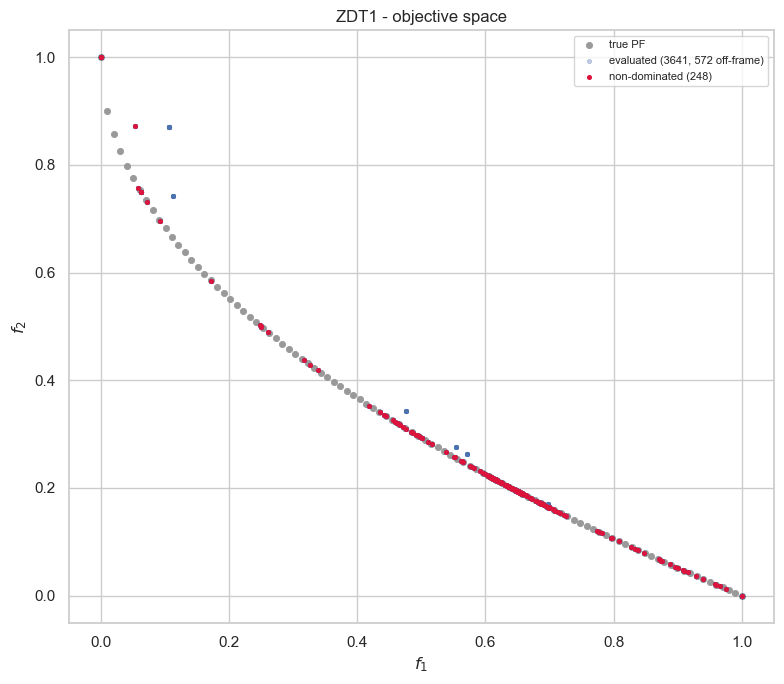

In [9]:
choquet_model.visualise("objective");

In [10]:
choquet_model.visualise("learning", show = False)

In [11]:
choquet_model.visualise("learning", plot_scalarisation = True, show = False)

# Benchmark

Every configuration is solved by both models from the same seed, then scored by `evaluate()` against one shared reference point.

- **ZDT1/2/3** are 2-objective by construction, so they appear once per `n_dim` and ignore `obj_dims`.
- **DTLZ1/2** take `n_obj`, and are skipped when `n_dim <= n_obj` - there would be no tail variables left to carry `g`.
- Hypervolume is comparable **within** a row group only; the reference point differs between configurations, so never compare it across problems or dimensions.

In [12]:
dec_dims   = [10, 20]
obj_dims   = [2, 3, 4, 5]
max_iter   = 50
model_list = [LinearModel, ChoquetModel]
prob_list  = [ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2]


def build(problem, n_dim, n_obj):
    """This grid cell's problem, or None if the combination does not exist: ZDT is 2-objective by
       construction, and DTLZ needs n_dim > n_obj to leave tail variables to carry g."""
    if problem in (ZDT1, ZDT2, ZDT3):
        return problem(n_dim = n_dim) if n_obj == 2 else None
    return problem(n_dim = n_dim, n_obj = n_obj) if n_dim > n_obj else None


rows = []
for problem, n_dim, n_obj in itertools.product(prob_list, dec_dims, obj_dims):
    prob = build(problem, n_dim, n_obj)
    if prob is None:
        continue

    fitted = [model(problem = prob, max_iter = max_iter, random_state = 42,
                    **(dict(method = 2) if model is ChoquetModel else {}))
              for model in model_list]
    for m in fitted:
        m.solve()

    # evaluate() scores the pair against one shared reference point, and already times each solve
    rows.append(evaluate(fitted).assign(problem = problem.__name__, n_dim = n_dim,
                                        n_obj = prob.n_obj))
    print(problem.__name__, f"n_dim={n_dim}", f"n_obj={prob.n_obj}",
          dict(rows[-1]["wallclock_time"].round(1)))

results = (pd.concat(rows).rename_axis("model").reset_index()
             .set_index(["problem", "n_dim", "n_obj", "model"]).sort_index())
results

ZDT1 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.4), 'ChoquetModel': np.float64(8.8)}
ZDT1 n_dim=20 n_obj=2 {'LinearModel': np.float64(1.0), 'ChoquetModel': np.float64(13.8)}
ZDT2 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(9.7)}
ZDT2 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.2), 'ChoquetModel': np.float64(1.2)}
ZDT3 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.6), 'ChoquetModel': np.float64(11.5)}
ZDT3 n_dim=20 n_obj=2 {'LinearModel': np.float64(2.6), 'ChoquetModel': np.float64(22.3)}
DTLZ1 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.5), 'ChoquetModel': np.float64(7.3)}
DTLZ1 n_dim=10 n_obj=3 {'LinearModel': np.float64(0.3), 'ChoquetModel': np.float64(20.1)}
DTLZ1 n_dim=10 n_obj=4 {'LinearModel': np.float64(0.4), 'ChoquetModel': np.float64(70.6)}
DTLZ1 n_dim=10 n_obj=5 {'LinearModel': np.float64(0.6), 'ChoquetModel': np.float64(89.2)}
DTLZ1 n_dim=20 n_obj=2 {'LinearModel': np.float64(1.0), 'ChoquetModel': np.float64(8.9)}
DTLZ1 n_dim=20 n_obj=

hypervolume  n_func_eval  n_non_dominated  \
problem n_dim n_obj model                                                      
DTLZ1   10    2     ChoquetModel  5.389288e+05         6941              328   
                    LinearModel   5.323304e+05         4961              234   
              3     ChoquetModel  2.136736e+08         7480              820   
                    LinearModel   2.133313e+08         3982              114   
              4     ChoquetModel  1.979215e+10        10670             1683   
                    LinearModel   1.977398e+10         4323              375   
              5     ChoquetModel  1.416610e+12         9603             1904   
                    LinearModel   1.416394e+12         5478             1015   
        20    2     ChoquetModel  2.254746e+06        18606              217   
                    LinearModel   2.251737e+06         9597              215   
              3     ChoquetModel  9.986410e+08        29841             1559   
                    LinearModel   9.881915e+08         9324              342   
              4     ChoquetModel  2.990061e+11        21189             1563   
                    LinearModel   2.973975e+11         9345              422   
              5     ChoquetModel  9.849379e+13        25473             3956   
                    LinearModel   9.823185e+13         9114              546   
DTLZ2   10    2     ChoquetModel  5.151053e+00         6886              631   
                    LinearModel   5.101749e+00         2398               16   
              3     ChoquetModel  1.335200e+01         1606               62   
                    LinearModel   1.374614e+01         2475               69   
              4     ChoquetModel  1.319439e+01         1859              189   
                    LinearModel   1.325398e+01         2431              228   
              5     ChoquetModel  4.819544e+01         4378              698   
                    LinearModel   4.810615e+01         2574              323   
        20    2     ChoquetModel  1.170651e+01         8568              341   
                    LinearModel   1.167993e+01         4683               32   
              3     ChoquetModel  5.629189e+01         3465               67   
                    LinearModel   5.625878e+01         4515               62   
              4     ChoquetModel  2.611043e+02        13125             1197   
                    LinearModel   2.608708e+02         4536              136   
              5     ChoquetModel  8.590383e+02         6468              611   
                    LinearModel   8.590561e+02         4473              229   
ZDT1    10    2     ChoquetModel  5.490907e+00         3641              506   
                    LinearModel   5.508354e+00         5346              754   
        20    2     ChoquetModel  5.250190e+00         9345              586   
                    LinearModel   5.258489e+00        10668              670   
ZDT2    10    2     ChoquetModel  6.466475e+00         4609              566   
                    LinearModel   6.282650e+00         1771               30   
        20    2     ChoquetModel  5.521041e+00         3885                2   
                    LinearModel   5.521041e+00         4284                4   
ZDT3    10    2     ChoquetModel  5.957663e+00         6875              396   
                    LinearModel   5.836037e+00         7942              382   
        20    2     ChoquetModel  5.561981e+00        21483              660   
                    LinearModel   5.561142e+00        17514              509   

                                  n_iter  wallclock_time  
problem n_dim n_obj model                                 
DTLZ1   10    2     ChoquetModel      50        7.306967  
                    LinearModel       50        0.468510  
              3     ChoquetModel      50       20.104556  
                    LinearModel       50        0.320761  


In [13]:
# hypervolume only compares within a configuration, so pick a winner per row
hv = results["hypervolume"].unstack("model")
hv.assign(winner = hv.idxmax(1), gap_pct = 100 * (hv.max(1) - hv.min(1)) / hv.max(1)).round(4)

model                ChoquetModel   LinearModel        winner  gap_pct
problem n_dim n_obj                                                   
DTLZ1   10    2      5.389288e+05  5.323304e+05  ChoquetModel   1.2244
              3      2.136736e+08  2.133313e+08  ChoquetModel   0.1602
              4      1.979215e+10  1.977398e+10  ChoquetModel   0.0918
              5      1.416610e+12  1.416394e+12  ChoquetModel   0.0153
        20    2      2.254746e+06  2.251737e+06  ChoquetModel   0.1335
              3      9.986410e+08  9.881915e+08  ChoquetModel   1.0464
              4      2.990061e+11  2.973975e+11  ChoquetModel   0.5380
              5      9.849379e+13  9.823185e+13  ChoquetModel   0.2659
DTLZ2   10    2      5.151100e+00  5.101700e+00  ChoquetModel   0.9572
              3      1.335200e+01  1.374610e+01   LinearModel   2.8673
              4      1.319440e+01  1.325400e+01   LinearModel   0.4497
              5      4.819540e+01  4.810620e+01  ChoquetModel   0.1853
        20    2      1.170650e+01  1.167990e+01  ChoquetModel   0.2270
              3      5.629190e+01  5.625880e+01  ChoquetModel   0.0588
              4      2.611043e+02  2.608708e+02  ChoquetModel   0.0894
              5      8.590383e+02  8.590561e+02   LinearModel   0.0021
ZDT1    10    2      5.490900e+00  5.508400e+00   LinearModel   0.3167
        20    2      5.250200e+00  5.258500e+00   LinearModel   0.1578
ZDT2    10    2      6.466500e+00  6.282600e+00  ChoquetModel   2.8427
        20    2      5.521000e+00  5.521000e+00  ChoquetModel   0.0000
ZDT3    10    2      5.957700e+00  5.836000e+00  ChoquetModel   2.0415
        20    2      5.562000e+00  5.561100e+00  ChoquetModel   0.0151